# NB-01: EDA & Schema Audit — CareerDNA / Redrob Candidate Ranking

**Goal:** Load the raw dataset, confirm schema against `candidate_schema.json`, audit nulls/dtypes/distributions across all three data layers (static profile, 23 behavioral signals, availability), and produce a cleaned `candidates.parquet` for downstream notebooks.

**Inputs:** `candidates.jsonl`, `candidate_schema.json`, `redrob_signals_doc.docx`, `job_description.docx`, `sample_candidates.json`

**Outputs:** `cleaned_candidates_v1.parquet`, `eda_report.json`

**Constraints reminder:** 100,000 candidates, 487MB uncompressed jsonl — must chunk-load, not read all at once naively.

In [1]:
import json
import os
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Base path from your Kaggle dataset mount
BASE = Path("/kaggle/input/datasets/kritikabenjwal/india-runs-data-and-ai-challenge-dataset/[PUB] India_runs_data_and_ai_challenge/[PUB] India_runs_data_and_ai_challenge/India_runs_data_and_ai_challenge")

# Confirm the folder exists and list contents
assert BASE.exists(), f"Path not found: {BASE}"
files = sorted(os.listdir(BASE))
for f in files:
    full_path = BASE / f
    size_mb = full_path.stat().st_size / (1024 * 1024)
    print(f"{f:45s} {size_mb:10.2f} MB")

README.docx                                         0.01 MB
candidate_schema.json                               0.01 MB
candidates.jsonl                                  464.69 MB
job_description.docx                                0.04 MB
redrob_signals_doc.docx                             0.04 MB
sample_candidates.json                              0.29 MB
sample_submission.csv                               0.01 MB
submission_metadata_template.yaml                   0.00 MB
submission_spec.docx                                0.04 MB
validate_submission.py                              0.00 MB


## Step 1: Confirm row count and inspect schema

Before loading 100K records, confirm the file actually has 100,000 lines, then load `candidate_schema.json` to understand every field we should expect.

In [2]:
# Confirm line count without loading full file into memory
with open(BASE / "candidates.jsonl", "r", encoding="utf-8") as f:
    line_count = sum(1 for _ in f)
print(f"Total candidate records: {line_count}")

# Load the schema
with open(BASE / "candidate_schema.json", "r", encoding="utf-8") as f:
    schema = json.load(f)

print("\n--- SCHEMA TOP-LEVEL KEYS ---")
print(json.dumps(schema, indent=2)[:3000])  # first 3000 chars to avoid flooding output

Total candidate records: 100000

--- SCHEMA TOP-LEVEL KEYS ---
{
  "$schema": "http://json-schema.org/draft-07/schema#",
  "title": "Redrob Candidate Profile Schema",
  "description": "Schema for a single candidate profile in the Intelligent Candidate Discovery & Ranking Challenge dataset.",
  "type": "object",
  "required": [
    "candidate_id",
    "profile",
    "career_history",
    "education",
    "skills",
    "redrob_signals"
  ],
  "properties": {
    "candidate_id": {
      "type": "string",
      "pattern": "^CAND_[0-9]{7}$",
      "description": "Unique identifier for the candidate. Format: CAND_XXXXXXX (7 digits)."
    },
    "profile": {
      "type": "object",
      "required": [
        "anonymized_name",
        "headline",
        "summary",
        "location",
        "country",
        "years_of_experience",
        "current_title",
        "current_company",
        "current_company_size",
        "current_industry"
      ],
      "properties": {
        "anonymize

## Step 2: Full schema (education, skills, redrob_signals) + one real candidate record

Print the remaining schema sections and load the first actual record from `candidates.jsonl` to sanity-check it matches what the schema promises.

In [3]:
# Print remaining schema sections explicitly
for section in ["education", "skills", "redrob_signals"]:
    print(f"\n{'='*20} {section.upper()} {'='*20}")
    if section in schema["properties"]:
        print(json.dumps(schema["properties"][section], indent=2))
    else:
        print(f"'{section}' not found as a top-level property — checking full schema keys:")
        print(list(schema["properties"].keys()))


==================== EDUCATION ====================
{
  "type": "array",
  "minItems": 0,
  "maxItems": 5,
  "items": {
    "type": "object",
    "required": [
      "institution",
      "degree",
      "field_of_study",
      "start_year",
      "end_year"
    ],
    "properties": {
      "institution": {
        "type": "string"
      },
      "degree": {
        "type": "string"
      },
      "field_of_study": {
        "type": "string"
      },
      "start_year": {
        "type": "integer",
        "minimum": 1970,
        "maximum": 2030
      },
      "end_year": {
        "type": "integer",
        "minimum": 1970,
        "maximum": 2035
      },
      "grade": {
        "type": [
          "string",
          "null"
        ],
        "description": "GPA / percentage / class."
      },
      "tier": {
        "type": "string",
        "enum": [
          "tier_1",
          "tier_2",
          "tier_3",
          "tier_4",
          "unknown"
        ],
        "descriptio

In [4]:
# Load and inspect the very first real candidate record
with open(BASE / "candidates.jsonl", "r", encoding="utf-8") as f:
    first_line = f.readline()
first_candidate = json.loads(first_line)

print(json.dumps(first_candidate, indent=2))

{
  "candidate_id": "CAND_0000001",
  "profile": {
    "anonymized_name": "Ira Vora",
    "headline": "Backend Engineer | SQL, Spark, Cloud",
    "summary": "Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid \u2014 Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side \u2014 Python, SQL, Spark, Airflow, warehouse design \u2014 and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I can leverage my existing data-infra skills while learning modern ML practice.",
    "location": "Toronto",
    "country": "Canada",
    "years_of_experience": 6.9,
    "current_title": "Backend Engineer",
    "current_company": "Mindtree",
    "current_company_size": "1

## Step 3: Load all 100,000 candidates and flatten into a DataFrame

We stream-parse the JSONL (one JSON object per line) rather than using `pd.read_json` directly, since nested structures (career_history, skills, redrob_signals) need controlled flattening. We'll keep nested fields as Python objects in the DataFrame for now (not fully flattened) — full feature-level flattening happens in NB-03.

In [5]:
import time

t0 = time.time()
records = []

with open(BASE / "candidates.jsonl", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

print(f"Loaded {len(records)} records in {time.time() - t0:.1f}s")

df = pd.DataFrame(records)
print(f"\nDataFrame shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMemory usage:")
print(df.memory_usage(deep=True).sort_values(ascending=False))

Loaded 100000 records in 8.6s

DataFrame shape: (100000, 8)

Columns: ['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals']

Memory usage:
redrob_signals    84000000
profile           28000000
skills            16793536
career_history    10178464
languages          9600000
education          9600000
certifications     7199392
candidate_id       6100000
Index                  132
dtype: int64


In [6]:
# Top-level null audit
print("--- NULL COUNTS (top-level columns) ---")
print(df.isnull().sum())

print("\n--- candidate_id uniqueness check ---")
print(f"Unique candidate_ids: {df['candidate_id'].nunique()} / {len(df)}")

print("\n--- Sample of profile column (first 2 rows) ---")
for i in range(2):
    print(f"\nRow {i}:")
    print(df.iloc[i]['profile'])

--- NULL COUNTS (top-level columns) ---
candidate_id      0
profile           0
career_history    0
education         0
skills            0
certifications    0
languages         0
redrob_signals    0
dtype: int64

--- candidate_id uniqueness check ---
Unique candidate_ids: 100000 / 100000

--- Sample of profile column (first 2 rows) ---

Row 0:
{'anonymized_name': 'Ira Vora', 'headline': 'Backend Engineer | SQL, Spark, Cloud', 'summary': "Software / data professional with 6.9 years of experience building data pipelines, backend systems, and analytics infrastructure. I'm a backend/data hybrid — Spark, Airflow, SQL warehouses are home territory; I'm building competence on the ML side. My toolkit is solid on the data engineering side — Python, SQL, Spark, Airflow, warehouse design — and I've completed a couple of self-directed ML projects (Kaggle competitions, side projects fine-tuning small models). Interested in transitioning toward more AI/ML-focused work, ideally at a company where I 

## Step 4: Flatten `profile` into top-level columns + first visualizations

`profile` is currently a dict per row. We extract its fields into proper DataFrame columns so we can run `.describe()`, plot distributions, and check for skew/outliers. career_history, education, skills, and redrob_signals stay nested for now — they get expanded in NB-03 (Feature Engineering).

In [7]:
# Flatten profile dict into top-level columns
profile_df = pd.json_normalize(df['profile'])
profile_df.columns = [f"profile_{c}" for c in profile_df.columns]

df_flat = pd.concat([df[['candidate_id']], profile_df, df[['career_history','education','skills','certifications','languages','redrob_signals']]], axis=1)

print(df_flat.shape)
print(df_flat[[c for c in df_flat.columns if c.startswith('profile_')]].describe(include='all').T)

(100000, 17)
                                 count unique                                                top   freq      mean       std  min  25%  50%  75%   max
profile_anonymized_name         100000   3312                                         Pooja Nair     55       NaN       NaN  NaN  NaN  NaN  NaN   NaN
profile_headline                100000   2469                   HR Manager | Helping teams scale   1853       NaN       NaN  NaN  NaN  NaN  NaN   NaN
profile_summary                 100000   3241  Professional with 7.5+ years of experience. I'...    190       NaN       NaN  NaN  NaN  NaN  NaN   NaN
profile_location                100000     28                                Bhubaneswar, Odisha   4321       NaN       NaN  NaN  NaN  NaN  NaN   NaN
profile_country                 100000      8                                              India  75113       NaN       NaN  NaN  NaN  NaN  NaN   NaN
profile_years_of_experience   100000.0    NaN                                          

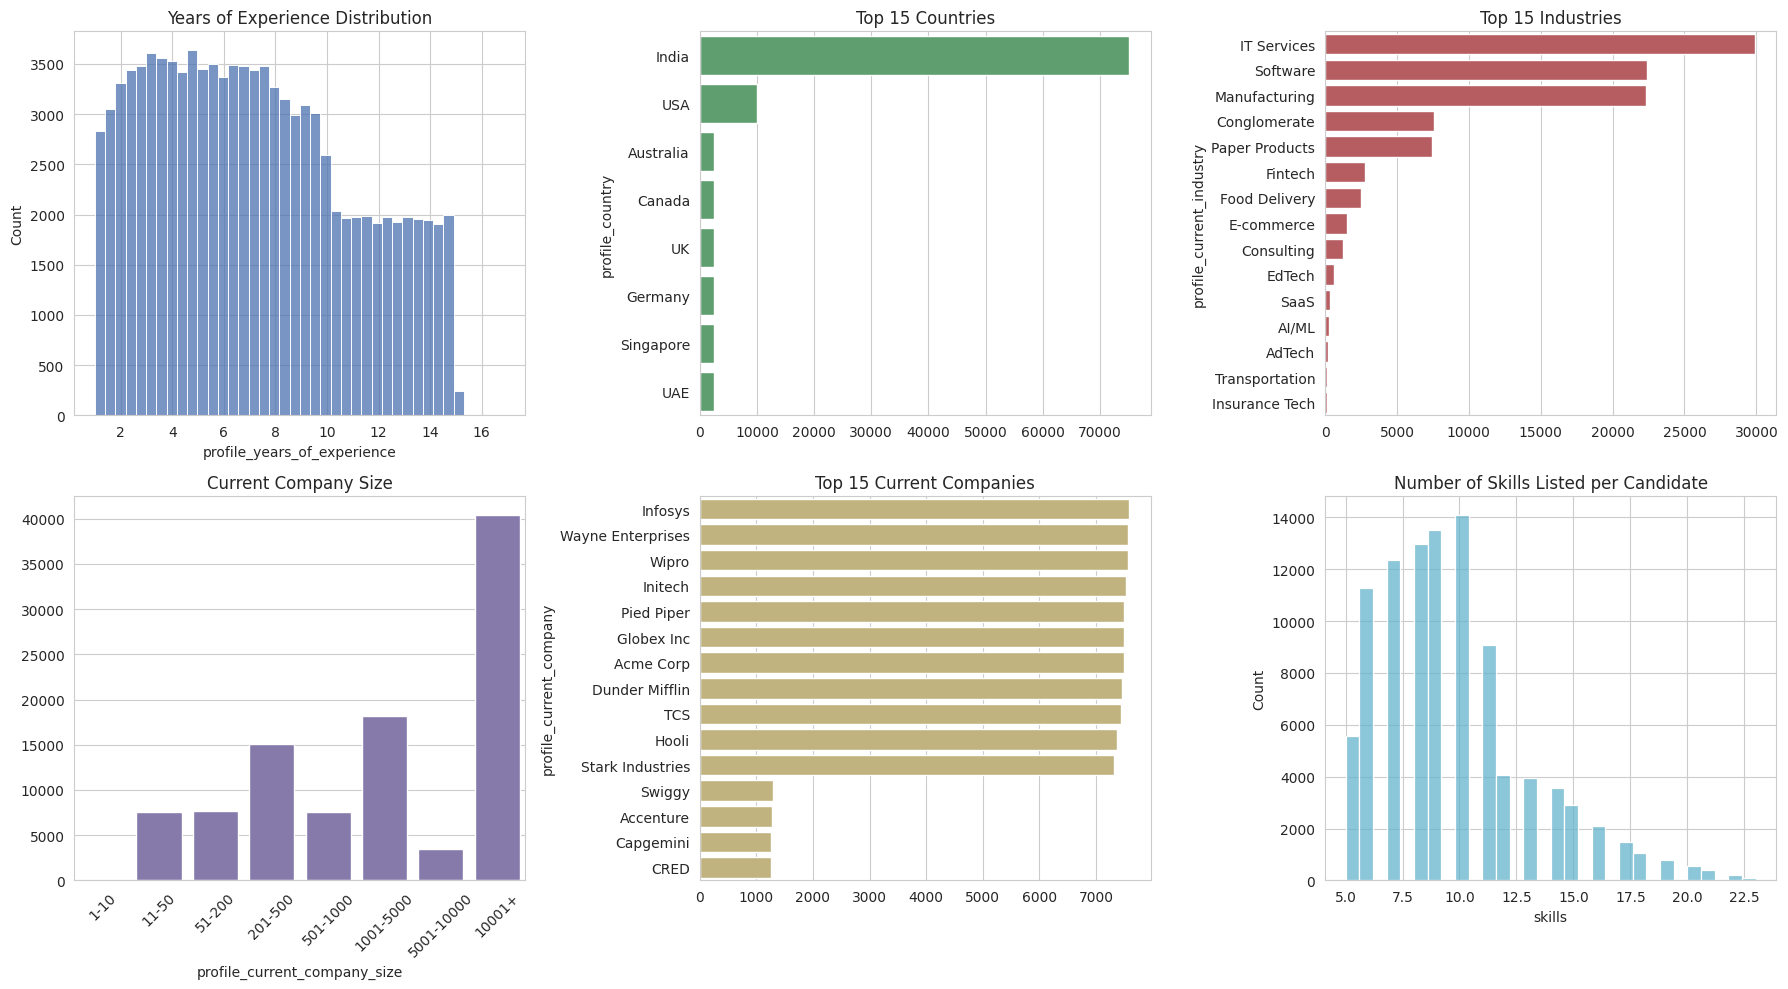


Skills count stats:
count    100000.00000
mean          9.60302
std           3.31163
min           5.00000
25%           7.00000
50%           9.00000
75%          11.00000
max          23.00000
Name: skills, dtype: float64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Years of experience distribution
sns.histplot(df_flat['profile_years_of_experience'], bins=40, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Years of Experience Distribution')

# 2. Country distribution (top 15)
top_countries = df_flat['profile_country'].value_counts().head(15)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0,1], color='#55A868')
axes[0,1].set_title('Top 15 Countries')

# 3. Current industry (top 15)
top_industry = df_flat['profile_current_industry'].value_counts().head(15)
sns.barplot(x=top_industry.values, y=top_industry.index, ax=axes[0,2], color='#C44E52')
axes[0,2].set_title('Top 15 Industries')

# 4. Company size distribution
size_order = ["1-10","11-50","51-200","201-500","501-1000","1001-5000","5001-10000","10001+"]
size_counts = df_flat['profile_current_company_size'].value_counts().reindex(size_order)
sns.barplot(x=size_counts.index, y=size_counts.values, ax=axes[1,0], color='#8172B2')
axes[1,0].set_title('Current Company Size')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Top current companies (top 15) -- check for consulting-firm concentration
top_companies = df_flat['profile_current_company'].value_counts().head(15)
sns.barplot(x=top_companies.values, y=top_companies.index, ax=axes[1,1], color='#CCB974')
axes[1,1].set_title('Top 15 Current Companies')

# 6. Skills count per candidate
skills_count = df_flat['skills'].apply(len)
sns.histplot(skills_count, bins=30, ax=axes[1,2], color='#64B5CD')
axes[1,2].set_title('Number of Skills Listed per Candidate')

plt.tight_layout()
plt.show()

print("\nSkills count stats:")
print(skills_count.describe())

## Step 5: Expand `redrob_signals` (23 behavioral signals) + sentinel value audit

Two fields use `-1` as a sentinel meaning "not applicable" rather than a real low value:
- `github_activity_score`: -1 = no GitHub linked
- `offer_acceptance_rate`: -1 = no offer history

We must NOT treat these as literal negative scores in any downstream model — they need a separate "has_github" / "has_offer_history" flag plus the -1 either imputed or masked.

In [9]:
# Pull skill_assessment_scores directly as a Series of raw dicts, from the un-normalized source
skill_assessment_col = df['redrob_signals'].apply(lambda d: d.get('skill_assessment_scores', {}))

# Now normalize redrob_signals as before (this WILL still explode skill_assessment_scores into dotted columns)
signals_raw = pd.json_normalize(df['redrob_signals'])

# Drop every column that came from flattening skill_assessment_scores (they all share this prefix)
sas_cols = [c for c in signals_raw.columns if c.startswith('skill_assessment_scores.')]
print(f"Dropping {len(sas_cols)} sparse skill_assessment_scores.* columns")
signals_raw = signals_raw.drop(columns=sas_cols)

signals_raw.columns = [f"sig_{c}" for c in signals_raw.columns]

# Rebuild df_flat cleanly
df_flat = pd.concat([
    df[['candidate_id']],
    profile_df,
    df[['career_history','education','skills','certifications','languages']],
    signals_raw,
], axis=1)
df_flat['skill_assessment_scores'] = skill_assessment_col  # kept nested (raw dict) for NB-03

print(f"\ndf_flat shape: {df_flat.shape}")  # expect (100000, ~30)
print(f"\nColumns: {list(df_flat.columns)}")

# Sentinel value counts
print("\n--- github_activity_score == -1 (no GitHub linked) ---")
print((df_flat['sig_github_activity_score'] == -1).sum(), "/", len(df_flat))

print("\n--- offer_acceptance_rate == -1 (no offer history) ---")
print((df_flat['sig_offer_acceptance_rate'] == -1).sum(), "/", len(df_flat))

df_flat['sig_has_github'] = (df_flat['sig_github_activity_score'] != -1).astype(int)
df_flat['sig_has_offer_history'] = (df_flat['sig_offer_acceptance_rate'] != -1).astype(int)

print("\n--- Numeric signal distributions (clean, 22 fixed signals) ---")
numeric_sig_cols = signals_raw.select_dtypes(include=[np.number]).columns.tolist()
print(signals_raw[numeric_sig_cols].describe().T)

print("\n--- Sanity check: skill_assessment_scores for first candidate ---")
print(df_flat['skill_assessment_scores'].iloc[0])

Dropping 56 sparse skill_assessment_scores.* columns

df_flat shape: (100000, 40)

Columns: ['candidate_id', 'profile_anonymized_name', 'profile_headline', 'profile_summary', 'profile_location', 'profile_country', 'profile_years_of_experience', 'profile_current_title', 'profile_current_company', 'profile_current_company_size', 'profile_current_industry', 'career_history', 'education', 'skills', 'certifications', 'languages', 'sig_profile_completeness_score', 'sig_signup_date', 'sig_last_active_date', 'sig_open_to_work_flag', 'sig_profile_views_received_30d', 'sig_applications_submitted_30d', 'sig_recruiter_response_rate', 'sig_avg_response_time_hours', 'sig_connection_count', 'sig_endorsements_received', 'sig_notice_period_days', 'sig_preferred_work_mode', 'sig_willing_to_relocate', 'sig_github_activity_score', 'sig_search_appearance_30d', 'sig_saved_by_recruiters_30d', 'sig_interview_completion_rate', 'sig_offer_acceptance_rate', 'sig_verified_email', 'sig_verified_phone', 'sig_linked

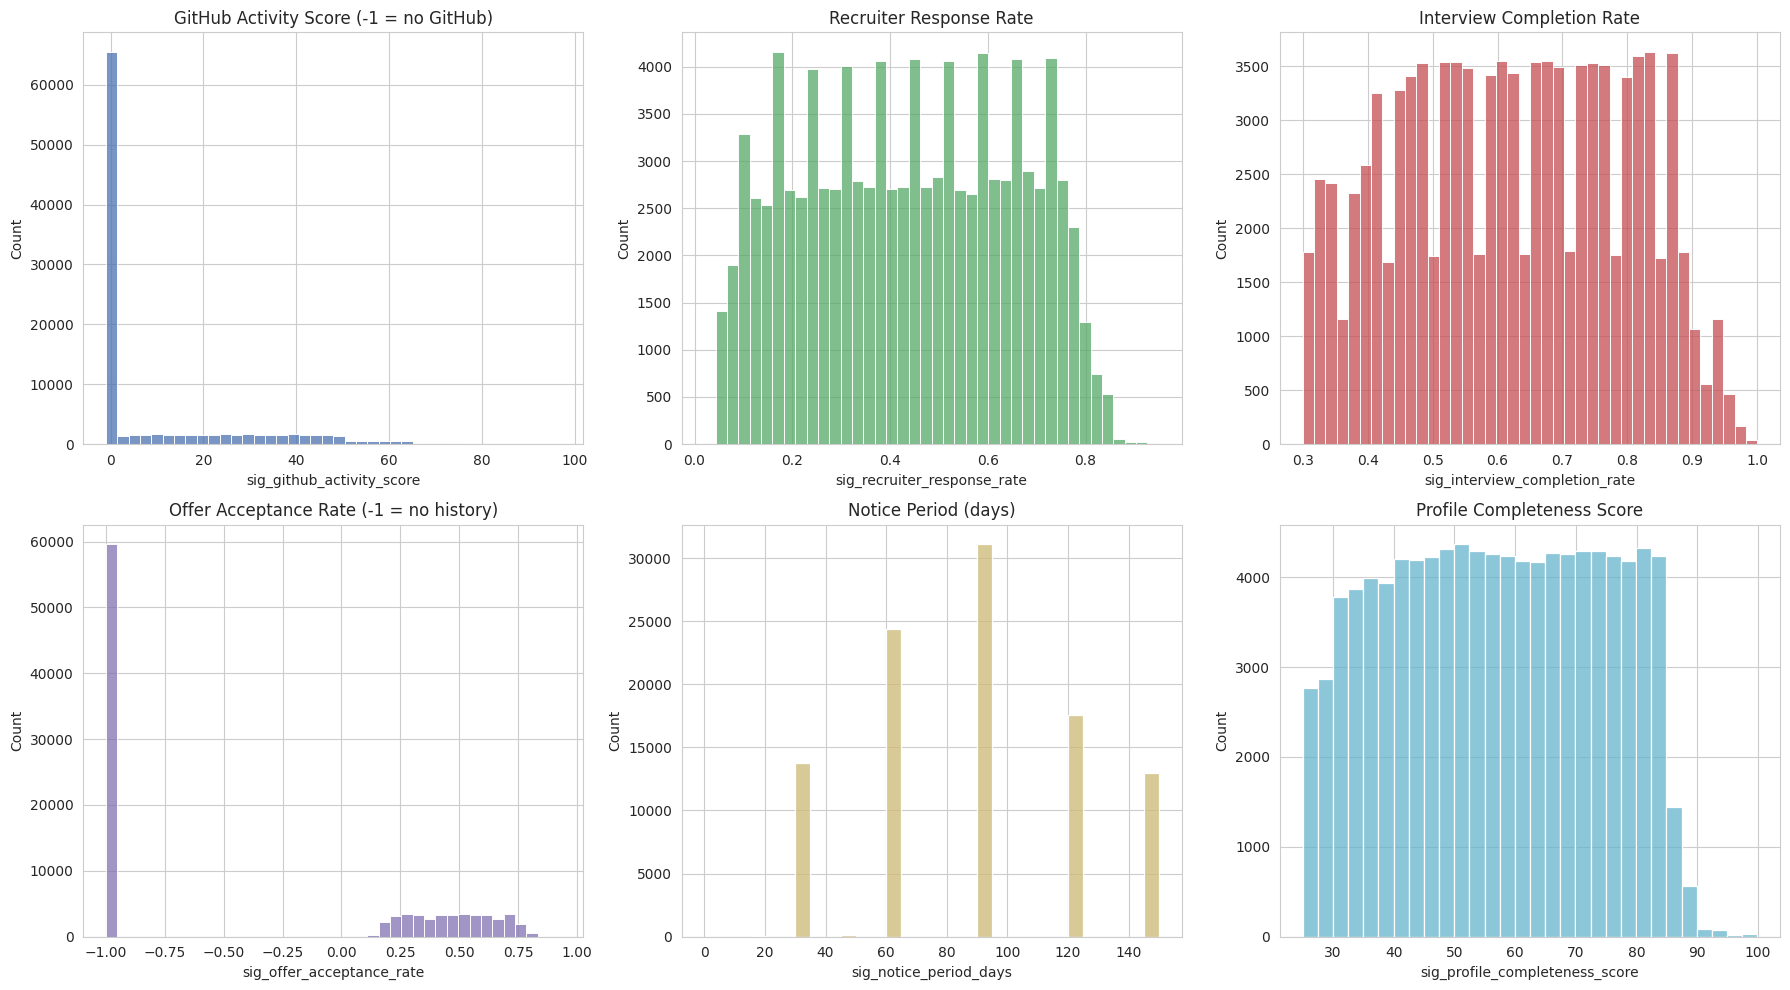

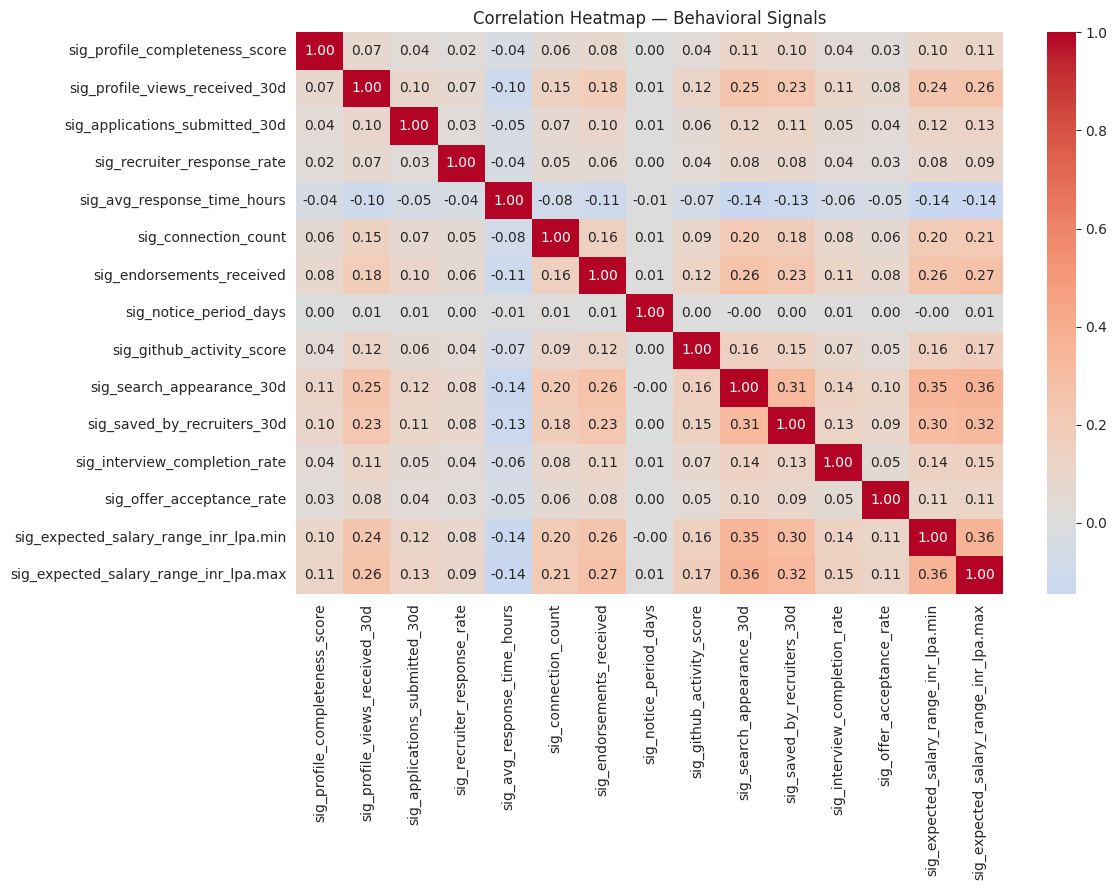

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(signals_raw['sig_github_activity_score'], bins=40, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('GitHub Activity Score (-1 = no GitHub)')

sns.histplot(signals_raw['sig_recruiter_response_rate'], bins=40, ax=axes[0,1], color='#55A868')
axes[0,1].set_title('Recruiter Response Rate')

sns.histplot(signals_raw['sig_interview_completion_rate'], bins=40, ax=axes[0,2], color='#C44E52')
axes[0,2].set_title('Interview Completion Rate')

sns.histplot(signals_raw['sig_offer_acceptance_rate'], bins=40, ax=axes[1,0], color='#8172B2')
axes[1,0].set_title('Offer Acceptance Rate (-1 = no history)')

sns.histplot(signals_raw['sig_notice_period_days'], bins=30, ax=axes[1,1], color='#CCB974')
axes[1,1].set_title('Notice Period (days)')

sns.histplot(signals_raw['sig_profile_completeness_score'], bins=30, ax=axes[1,2], color='#64B5CD')
axes[1,2].set_title('Profile Completeness Score')

plt.tight_layout()
plt.show()

# Correlation heatmap of numeric signals
plt.figure(figsize=(12,9))
corr = signals_raw[numeric_sig_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Behavioral Signals')
plt.tight_layout()
plt.show()

## Step 6: Career history & skills — anti-consulting pattern + claimed-vs-verified skill gap

Two features tied directly to the JD's explicit traps:
1. **Anti-consulting flag** — entire career history at consulting-only firms (TCS, Infosys, Wipro, Accenture, Cognizant, Capgemini) with no product-company stint
2. **Skill claim-vs-verified gap** — candidates who list many "advanced/expert" skills but have few or no `skill_assessment_scores` backing them up (the exact Marketing-Manager-with-AI-skills trap)

In [11]:
CONSULTING_FIRMS = {'TCS', 'Infosys', 'Wipro', 'Accenture', 'Cognizant', 'Capgemini'}

def is_consulting_only_career(career_history):
    companies = {job['company'] for job in career_history}
    return companies.issubset(CONSULTING_FIRMS)

df_flat['flag_consulting_only_career'] = df['career_history'].apply(is_consulting_only_career)
print("Consulting-only career count:", df_flat['flag_consulting_only_career'].sum(), "/", len(df_flat))

# Career history length distribution
career_len = df['career_history'].apply(len)
print("\nCareer history length (# jobs) stats:")
print(career_len.describe())

# Claimed skills: count of advanced/expert proficiency skills
def count_high_proficiency_skills(skills_list):
    return sum(1 for s in skills_list if s['proficiency'] in ('advanced', 'expert'))

df_flat['claimed_high_prof_skill_count'] = df['skills'].apply(count_high_proficiency_skills)
df_flat['total_skill_count'] = df['skills'].apply(len)
df_flat['verified_skill_count'] = df_flat['skill_assessment_scores'].apply(len)

# The gap: how many high-proficiency-claimed skills have ZERO verification at all
def unverified_high_prof_count(row):
    skills_list = row['skills_raw']
    verified_keys = set(row['skill_assessment_scores'].keys())
    return sum(1 for s in skills_list if s['proficiency'] in ('advanced','expert') and s['name'] not in verified_keys)

df_flat['skills_raw'] = df['skills']  # temp column for the apply above
df_flat['unverified_high_prof_count'] = df_flat.apply(unverified_high_prof_count, axis=1)
df_flat = df_flat.drop(columns=['skills_raw'])

print("\nclaimed_high_prof_skill_count stats:")
print(df_flat['claimed_high_prof_skill_count'].describe())
print("\nverified_skill_count stats:")
print(df_flat['verified_skill_count'].describe())
print("\nunverified_high_prof_count stats:")
print(df_flat['unverified_high_prof_count'].describe())

# Cross-tab: consulting-only career vs unverified skill claims -- this is the trap population
trap_candidates = df_flat[(df_flat['flag_consulting_only_career']) & (df_flat['unverified_high_prof_count'] >= 3)]
print(f"\nLikely trap candidates (consulting-only + 3+ unverified 'advanced' skills): {len(trap_candidates)}")
print(trap_candidates[['candidate_id','profile_current_title','profile_current_company','claimed_high_prof_skill_count','verified_skill_count']].head(10))

Consulting-only career count: 7034 / 100000

Career history length (# jobs) stats:
count    100000.000000
mean          3.001710
std           1.522442
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           9.000000
Name: career_history, dtype: float64

claimed_high_prof_skill_count stats:
count    100000.000000
mean          1.108960
std           1.934395
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: claimed_high_prof_skill_count, dtype: float64

verified_skill_count stats:
count    100000.000000
mean          0.358950
std           0.772626
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           5.000000
Name: verified_skill_count, dtype: float64

unverified_high_prof_count stats:
count    100000.000000
mean          0.750540
std           1.745589
min           0.000000
25%           0.000000
50%           0.

## Step 7: Correcting our heuristics against the authoritative spec

Two things to fix from Step 6:
1. **Anti-consulting flag** was checking "entire career at consulting firms" — this matches the JD's wording exactly, good. Keep as-is.
2. **We do NOT yet have a honeypot detector.** What we built in Step 6 (unverified skill claims) is the "keyword-stuffing trap" pattern, separate from honeypots. Honeypots are defined by the spec as *internally impossible* profiles:
   - "expert" proficiency skill with `duration_months` near 0
   - `years_of_experience` inconsistent with the sum of `career_history` durations
   - (possibly) company tenure that doesn't reconcile with a company's plausible founding date — we don't have founding dates in the schema, so this check isn't directly buildable; skip it and rely on the two checks above, which are directly computable from the schema fields we have.

This distinction matters: honeypot rate is a **hard Stage 3 pass/fail gate**, not part of the composite score. We must get this detector right independently of the ranking quality.

In [12]:
# --- Honeypot detector: internal logical impossibility, NOT unverified-skill-claim trap ---

def honeypot_expert_zero_duration(skills_list, threshold_months=6):
    """Flag: 'expert' proficiency claimed with near-zero duration_months."""
    return any(
        s['proficiency'] == 'expert' and s.get('duration_months', 0) <= threshold_months
        for s in skills_list
    )

def honeypot_yoe_mismatch(years_of_experience, career_history, tolerance_years=2.0):
    """Flag: stated years_of_experience wildly inconsistent with sum of career_history durations."""
    total_months = sum(job.get('duration_months', 0) for job in career_history)
    total_years_from_history = total_months / 12.0
    return abs(years_of_experience - total_years_from_history) > tolerance_years

df_flat['honeypot_expert_zero_duration'] = df['skills'].apply(honeypot_expert_zero_duration)

df_flat['honeypot_yoe_mismatch'] = df.apply(
    lambda row: honeypot_yoe_mismatch(row['profile']['years_of_experience'], row['career_history']),
    axis=1
)

df_flat['is_honeypot_candidate'] = df_flat['honeypot_expert_zero_duration'] | df_flat['honeypot_yoe_mismatch']

print("honeypot_expert_zero_duration count:", df_flat['honeypot_expert_zero_duration'].sum())
print("honeypot_yoe_mismatch count:", df_flat['honeypot_yoe_mismatch'].sum())
print("is_honeypot_candidate (either flag) count:", df_flat['is_honeypot_candidate'].sum())
print("\nExpected ballpark: ~80 (per spec). If we're wildly off, thresholds need tuning.")

# Inspect a few flagged honeypots
print("\n--- Sample flagged honeypots ---")
hp_sample = df_flat[df_flat['is_honeypot_candidate']].head(10)
print(hp_sample[['candidate_id','profile_years_of_experience','honeypot_expert_zero_duration','honeypot_yoe_mismatch']])

honeypot_expert_zero_duration count: 21
honeypot_yoe_mismatch count: 48
is_honeypot_candidate (either flag) count: 69

Expected ballpark: ~80 (per spec). If we're wildly off, thresholds need tuning.

--- Sample flagged honeypots ---
       candidate_id  profile_years_of_experience  honeypot_expert_zero_duration  honeypot_yoe_mismatch
1609   CAND_0001610                          3.0                          False                   True
3429   CAND_0003430                         13.7                          False                   True
3581   CAND_0003582                          8.2                           True                  False
5290   CAND_0005291                         12.8                          False                   True
7352   CAND_0007353                          9.9                          False                   True
7412   CAND_0007413                         13.3                          False                   True
8959   CAND_0008960                         10

## Step 9: Education, certifications, languages — quick audit

Last three nested fields we haven't touched. Quick distributional check before we finalize and save.

In [13]:
# Education: institution tier distribution, degree field
def get_tiers(edu_list):
    return [e.get('institution_tier') for e in edu_list if 'institution_tier' in e]

all_tiers = [t for edu in df['education'] for t in get_tiers(edu)]
print("--- Institution tier distribution (all degrees, all candidates) ---")
print(pd.Series(all_tiers).value_counts())

edu_count = df['education'].apply(len)
print("\nEducation entries per candidate:")
print(edu_count.describe())
print("Candidates with 0 education entries:", (edu_count == 0).sum())

# Certifications
cert_count = df['certifications'].apply(len)
print("\nCertifications per candidate:")
print(cert_count.describe())

# Languages
lang_count = df['languages'].apply(len)
print("\nLanguages per candidate:")
print(lang_count.describe())

# Highest institution tier per candidate (tier_1 = best) -- useful engineered feature preview
TIER_RANK = {'tier_1': 4, 'tier_2': 3, 'tier_3': 2, 'tier_4': 1}
def best_tier_score(edu_list):
    tiers = get_tiers(edu_list)
    if not tiers:
        return 0
    return max(TIER_RANK.get(t, 0) for t in tiers)

df_flat['best_institution_tier_score'] = df['education'].apply(best_tier_score)
print("\nbest_institution_tier_score distribution:")
print(df_flat['best_institution_tier_score'].value_counts().sort_index())

--- Institution tier distribution (all degrees, all candidates) ---
Series([], Name: count, dtype: int64)

Education entries per candidate:
count    100000.000000
mean          1.397780
std           0.489442
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max           2.000000
Name: education, dtype: float64
Candidates with 0 education entries: 0

Certifications per candidate:
count    100000.000000
mean          0.374840
std           0.696046
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           3.000000
Name: certifications, dtype: float64

Languages per candidate:
count    100000.0
mean          2.0
std           0.0
min           2.0
25%           2.0
50%           2.0
75%           2.0
max           2.0
Name: languages, dtype: float64

best_institution_tier_score distribution:
best_institution_tier_score
0    100000
Name: count, dtype: int64


## Step 9b: Fix — inspect real `education` record structure

`institution_tier` returned nothing — wrong key name assumed. Check the actual schema + a real record before rebuilding the tier feature.

In [14]:
# Check the actual schema definition for education fields
print("--- Schema: education item properties ---")
print(json.dumps(schema["properties"]["education"]["items"]["properties"], indent=2))

# Check a real raw record
print("\n--- Real education record samples ---")
for i in range(3):
    print(f"\nCandidate {i} education:")
    print(df['education'].iloc[i])

--- Schema: education item properties ---
{
  "institution": {
    "type": "string"
  },
  "degree": {
    "type": "string"
  },
  "field_of_study": {
    "type": "string"
  },
  "start_year": {
    "type": "integer",
    "minimum": 1970,
    "maximum": 2030
  },
  "end_year": {
    "type": "integer",
    "minimum": 1970,
    "maximum": 2035
  },
  "grade": {
    "type": [
      "string",
      "null"
    ],
    "description": "GPA / percentage / class."
  },
  "tier": {
    "type": "string",
    "enum": [
      "tier_1",
      "tier_2",
      "tier_3",
      "tier_4",
      "unknown"
    ],
    "description": "Internal tiering for institution prestige."
  }
}

--- Real education record samples ---

Candidate 0 education:
[{'institution': 'Lovely Professional University', 'degree': 'B.E.', 'field_of_study': 'Computer Science', 'start_year': 2017, 'end_year': 2020, 'grade': '8.24 CGPA', 'tier': 'tier_3'}]

Candidate 1 education:
[{'institution': 'Local Engineering College', 'degree': 'B

## Step 9c: Corrected institution tier feature

In [15]:
TIER_RANK = {'tier_1': 4, 'tier_2': 3, 'tier_3': 2, 'tier_4': 1, 'unknown': 0}

def get_tiers(edu_list):
    return [e.get('tier') for e in edu_list if 'tier' in e]

all_tiers = [t for edu in df['education'] for t in get_tiers(edu)]
print("--- Institution tier distribution (all degrees, all candidates) ---")
print(pd.Series(all_tiers).value_counts())

def best_tier_score(edu_list):
    tiers = get_tiers(edu_list)
    if not tiers:
        return 0
    return max(TIER_RANK.get(t, 0) for t in tiers)

df_flat['best_institution_tier_score'] = df['education'].apply(best_tier_score)
print("\nbest_institution_tier_score distribution:")
print(df_flat['best_institution_tier_score'].value_counts().sort_index())

# Also worth knowing: how many candidates have ANY 'unknown' tier degree (data quality flag, not a real signal)
has_unknown_tier = df['education'].apply(lambda edu: 'unknown' in get_tiers(edu))
print("\nCandidates with at least one 'unknown' tier degree:", has_unknown_tier.sum())

--- Institution tier distribution (all degrees, all candidates) ---
tier_3    53220
tier_4    51885
tier_2    27821
tier_1     6852
Name: count, dtype: int64

best_institution_tier_score distribution:
best_institution_tier_score
1    30776
2    39815
3    22996
4     6413
Name: count, dtype: int64

Candidates with at least one 'unknown' tier degree: 0


## Step 10: Save cleaned artifacts — close NB-01

Save `df_flat` (structured/flattened fields, still keeping `career_history`, `education`, `skills`, `skill_assessment_scores` as nested objects for downstream notebooks) plus the original `df` for full raw access, and a JSON summary of this EDA for the writeup.

In [16]:
import os

OUT_DIR = Path("/kaggle/working")
OUT_DIR.mkdir(exist_ok=True)

# Save cleaned flattened frame (nested cols stay as objects — parquet handles this via pyarrow)
df_flat.to_parquet(OUT_DIR / "cleaned_candidates_v1.parquet", engine="pyarrow", index=False)
print("Saved cleaned_candidates_v1.parquet")
print("Shape:", df_flat.shape)
print("Size on disk:", (OUT_DIR / "cleaned_candidates_v1.parquet").stat().st_size / (1024*1024), "MB")

# EDA summary report
eda_report = {
    "total_candidates": int(len(df_flat)),
    "unique_candidate_ids": int(df_flat['candidate_id'].nunique()),
    "years_of_experience": {
        "mean": float(df_flat['profile_years_of_experience'].mean()),
        "median": float(df_flat['profile_years_of_experience'].median()),
    },
    "country_distribution": df_flat['profile_country'].value_counts().to_dict(),
    "top_industries": df_flat['profile_current_industry'].value_counts().head(10).to_dict(),
    "sentinel_rates": {
        "no_github_pct": float((df_flat['sig_github_activity_score'] == -1).mean() * 100),
        "no_offer_history_pct": float((df_flat['sig_offer_acceptance_rate'] == -1).mean() * 100),
    },
    "consulting_only_career_count": int(df_flat['flag_consulting_only_career'].sum()),
    "keyword_stuffing_trap_candidates": int(len(trap_candidates)),
    "honeypot_candidates_detected": {
        "expert_zero_duration": int(df_flat['honeypot_expert_zero_duration'].sum()),
        "yoe_mismatch": int(df_flat['honeypot_yoe_mismatch'].sum()),
        "total_flagged": int(df_flat['is_honeypot_candidate'].sum()),
        "spec_expected_ballpark": 80,
    },
    "institution_tier_distribution": pd.Series(all_tiers).value_counts().to_dict(),
    "notes": [
        "notice_period_days is quantized (30/60/90/120/150), treat as ordinal not continuous",
        "skill_assessment_scores kept as nested dict per candidate, NOT flattened wide (was 56 sparse columns)",
        "honeypot detector v1 uses only 2 of possible checks (no company founding-date data available)",
        "median verified_skill_count across dataset is 0 -- has_any_verification is itself a strong signal"
    ]
}

with open(OUT_DIR / "eda_report.json", "w") as f:
    json.dump(eda_report, f, indent=2)

print("\nSaved eda_report.json")
print(json.dumps(eda_report, indent=2)[:2000])

Saved cleaned_candidates_v1.parquet
Shape: (100000, 51)
Size on disk: 14.697610855102539 MB

Saved eda_report.json
{
  "total_candidates": 100000,
  "unique_candidate_ids": 100000,
  "years_of_experience": {
    "mean": 7.166318999999999,
    "median": 6.8
  },
  "country_distribution": {
    "India": 75113,
    "USA": 9978,
    "Australia": 2579,
    "Canada": 2506,
    "UK": 2472,
    "Germany": 2469,
    "Singapore": 2453,
    "UAE": 2430
  },
  "top_industries": {
    "IT Services": 29881,
    "Software": 22417,
    "Manufacturing": 22305,
    "Conglomerate": 7571,
    "Paper Products": 7467,
    "Fintech": 2808,
    "Food Delivery": 2514,
    "E-commerce": 1529,
    "Consulting": 1274,
    "EdTech": 610
  },
  "sentinel_rates": {
    "no_github_pct": 64.637,
    "no_offer_history_pct": 59.553999999999995
  },
  "consulting_only_career_count": 7034,
  "keyword_stuffing_trap_candidates": 560,
  "honeypot_candidates_detected": {
    "expert_zero_duration": 21,
    "yoe_mismatch": 48,